In [3]:
import pandas as pd 
import numpy 
import yfinance as yf # market data
import matplotlib.pyplot as plt
import seaborn as sns 


## 1. Download data 

In [12]:

ticker = "AAPL" # a ticker is a symbol/series of letters assigned to a stock 
df = yf.download(ticker, start="2020-01-01", end="2025-31-01")
df.head()

C:\Users\Admin\AppData\Local\Temp\ipykernel_24136\1690830598.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start="2020-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.400520,72.460784,71.156682,71.409785,135480400
2020-01-03,71.696640,72.455958,71.472462,71.629145,146322800
2020-01-06,72.267929,72.306499,70.568503,70.819201,118387200
2020-01-07,71.928062,72.533103,71.708703,72.277586,108872000
2020-01-08,73.085114,73.386431,71.631559,71.631559,132079200




    - Close (Closing Price): The price of the final trade for a stock during a specific trading session. 
    - High (High Price): The maximum (highest) price the stock traded.
    - Low (Low Price): The minimum (lowest) price the stock traded at.
    - Volume (Volume): The total number of shares or contracts that were traded during that period. 

In [13]:
df = df[['Close']] # new dataframe
df.head()

Price,Close
Ticker,AAPL
Date,
2020-01-02,72.400520
2020-01-03,71.696640
2020-01-06,72.267929
2020-01-07,71.928062
2020-01-08,73.085114


## 2. Basic time series plot 

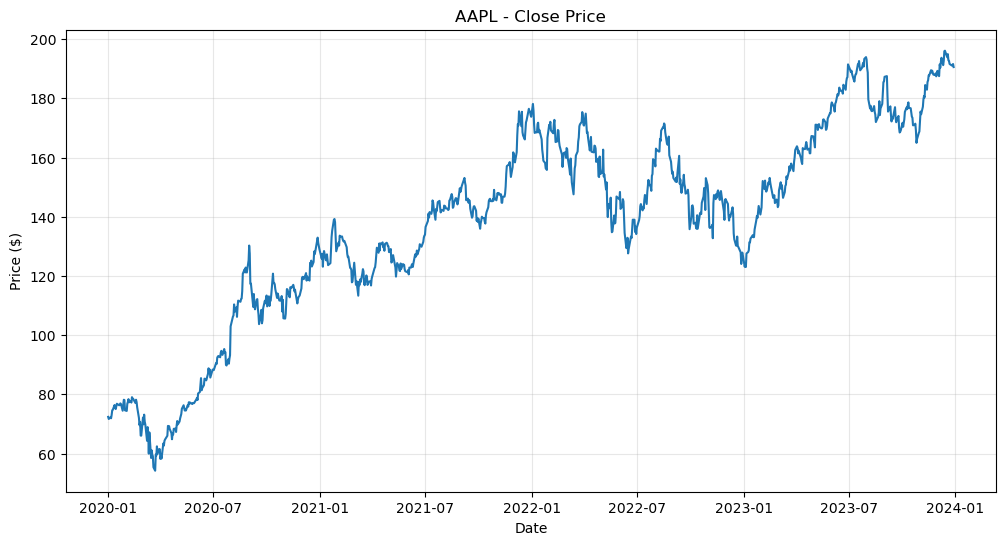

In [14]:

plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Close'])
plt.title(f'{ticker} - Close Price')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.grid(True, alpha=0.3) # turns on grid lines with 30% opacity 
plt.show()

## 3. Extract time features

In [15]:

df['Year'] = df.index.year
df['Month'] = df.index.month
df['Day'] = df.index.day
df['DayOfWeek'] = df.index.dayofweek
df['Quarter'] = df.index.quarter

print("Time Features Extracted:")
print(df.head())

Time Features Extracted:
Price           Close  Year Month Day DayOfWeek Quarter
Ticker           AAPL                                  
Date                                                   
2020-01-02  72.400520  2020     1   2         3       1
2020-01-03  71.696640  2020     1   3         4       1
2020-01-06  72.267929  2020     1   6         0       1
2020-01-07  71.928062  2020     1   7         1       1
2020-01-08  73.085114  2020     1   8         2       1


## 4. More plots to look at patterns 

In [ ]:
df['Trend_30d'] = df['Close'].rolling(window=30).mean()
#this is a simple moving average

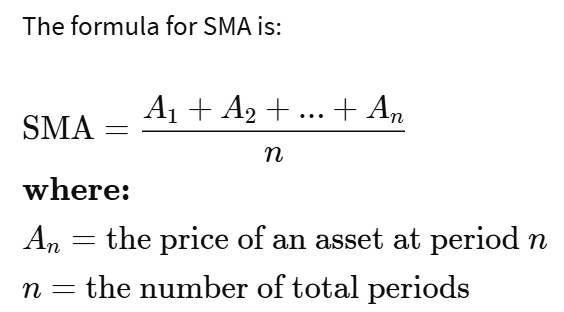

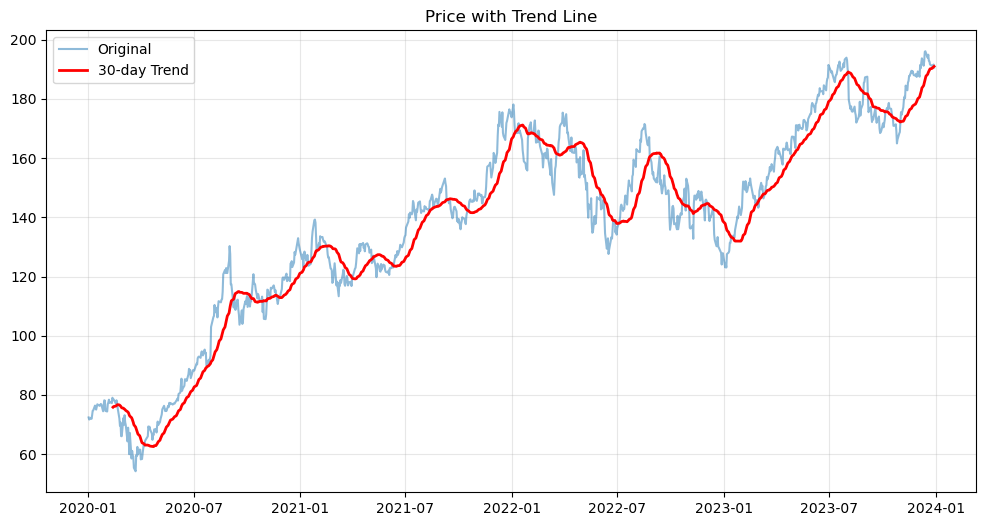

In [16]:


plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Close'], alpha=0.5, label='Original')
plt.plot(df.index, df['Trend_30d'], color='red', linewidth=2, label='30-day Trend')
plt.title('Price with Trend Line')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_24136\3203559323.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_monthly = df['Close'].resample('M').mean()


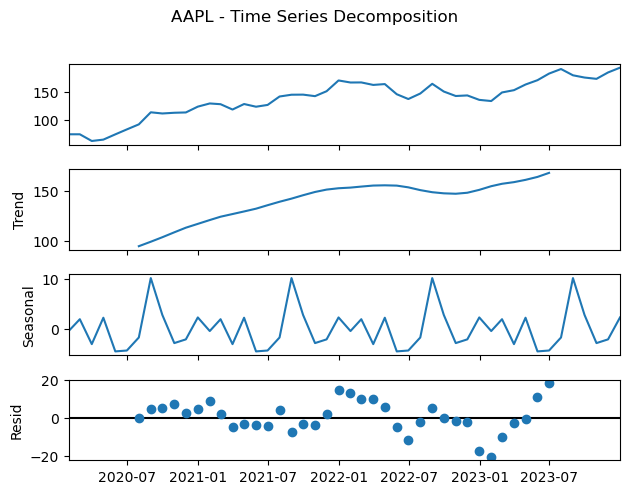

In [21]:
from statsmodels.tsa.seasonal import seasonal_decompose

df_monthly = df['Close'].resample('M').mean()


decomposition = seasonal_decompose(df_monthly, model='additive', period=12)

# Plot all components at once
decomposition.plot()
plt.suptitle(f'{ticker} - Time Series Decomposition', y=1.02)
plt.tight_layout()
plt.show()

## 5. Train Test Split

In [22]:
# This is 80/20 split though indexing 
split_idx = int(len(df) * 0.8)
train= df[:split_idx]
test = df[split_idx:]

print(f"Train: {train.index[0].date()} to {train.index[-1].date()}")
print(f"Test: {test.index[0].date()} to {test.index[-1].date()}")

Train: 2020-01-02 to 2023-03-13
Test: 2023-03-14 to 2023-12-29


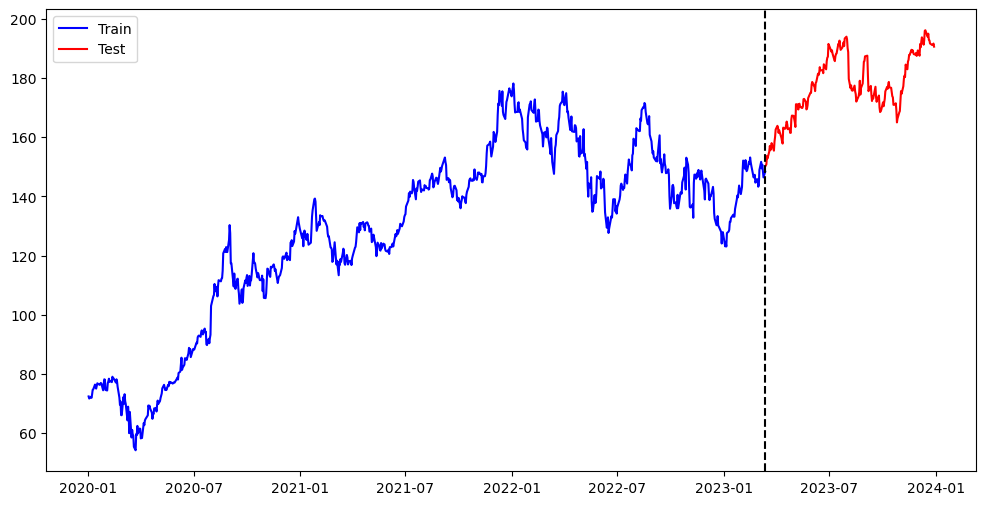

In [23]:

plt.figure(figsize=(12, 6))
plt.plot(train.index, train['Close'], 'b-', test.index, test['Close'], 'r-')
plt.axvline(x=train.index[-1], color='k', linestyle='--')
plt.legend(['Train', 'Test'])
plt.show()